In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'
text_emb_128 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_128.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Using device: cuda


# KNN based Model - on textual embeddings
By leveraging textual embeddings (128-dimensional vectors representing paper content), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with embedding

In [2]:
df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


In [3]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline Model

[KNN] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN] Starting training...
Selected 21625/2162513
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      9379
           1     1.0000    1.0000    1.0000     12246

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



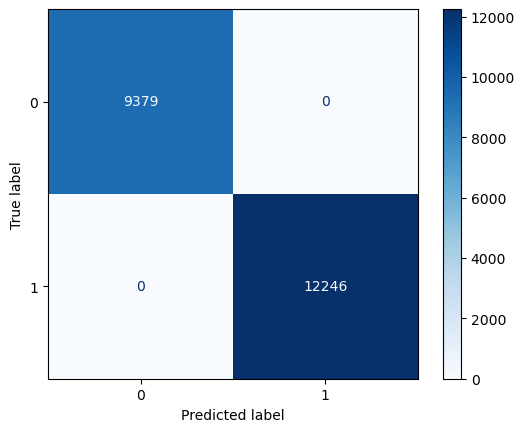

In [4]:
KNN_baseline = KNNModel('KNN_baseline', n_jobs=N_JOBS, n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline = KNNModel()

KNN_baseline.train_pipeline(df_train)

The confusion matrix for the training set shows an accuracy of 100%. This indicates severe overfitting, most probably because the number of neighbors is set to 5, that is relatively small and it's evaluated on the same data it stored, ending in just memorizing the training set instead of generalize the predictions.

[KNN] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.5006
1    0.4994
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7385    0.6912    0.7141      5006
           1     0.7091    0.7547    0.7312      4994

    accuracy                         0.7229     10000
   macro avg     0.7238    0.7229    0.7226     10000
weighted avg     0.7238    0.7229    0.7226     10000



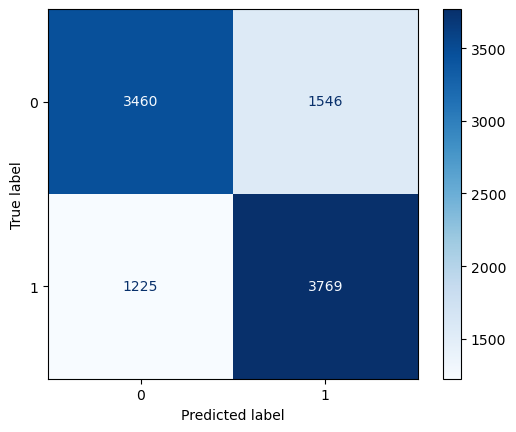

In [5]:
KNN_baseline.test_pipeline(df_test.sample(10000))

The baseline KNN model that use 128-dimensional embeddings achieved an accuracy of 72.29%. The confusion matrix shows a balanced performance, with slightly higher number  of false positives and true positives. 

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [6]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

[KNN_textual_128] Grid Search...
[KNN_textual_128] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_textual_128] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 50000 samples...

Best parameters found:
{'metric': 'manhattan', 'n_neighbors': 12, 'weights': 'uniform'}

Optimal model ready: KNeighborsClassifier(metric='manhattan', n_jobs=-1, n_neighbors=12)
[KNN_textual_128] Train model with best params...
[KNN_textual_128] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_textual_128] Starting training...
Selected 10812/2162513
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      4782
           1     1.0000    1.0000    1.0000      6030

    accuracy                         1.000

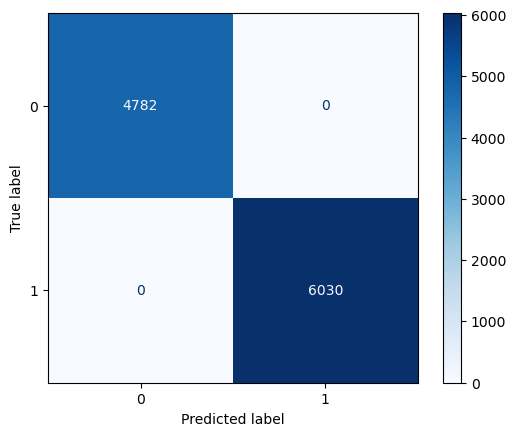

In [7]:
# tuning
KNN_textual = KNNModel("KNN_textual_128")
KNN_textual.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS,
                               frac=0.005)

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

[KNN_textual_128] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.5027
1    0.4973
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7116    0.7901    0.7488      5027
           1     0.7612    0.6763    0.7162      4973

    accuracy                         0.7335     10000
   macro avg     0.7364    0.7332    0.7325     10000
weighted avg     0.7363    0.7335    0.7326     10000



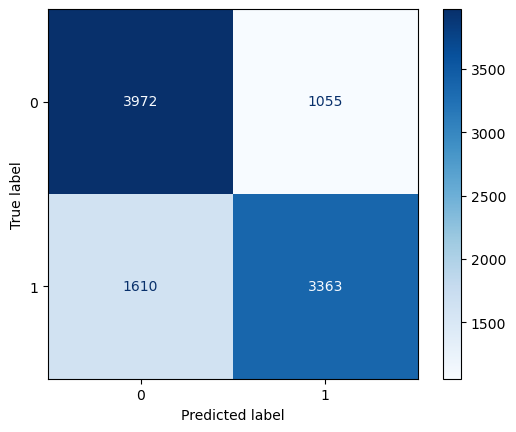

In [8]:
KNN_textual.test_pipeline(df_test.sample(10000))

After performing some fine tuning and increasing the number of neighbors to 12, the model just slightly increased to 73.35% of accuracy, but the imbalance of the performance increased, shifting the model to increase the number of false negatives and being more capable of identifying invalid references.

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [9]:
from utils.model_saver import save_model_artifact

save_model_artifact(KNN_textual, df_name=text_emb_128.name, 
                    model_name="Best_KNN_textual_128", 
                    relative_model_dir=MODEL_SAVE_PATH)